# Saliency Maps

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pkg.saliency_maps.compute_gradient import run_forecast_with_gradients
from pkg.gcs_utils.client import download_file

## Run Forecast

In [2]:
import os

os.makedirs("data/data_for_climatology", exist_ok=True)
os.makedirs("data/prediction_zeynep_22/input_data", exist_ok=True)

In [3]:
# Run on server

# Get files from bucket climatology and input data
download_file(
    blob_path="data/data_for_climatology/era5_1979-2015_0218_climatology.nc",
    local_path="data/data_for_climatology/era5_1979-2015_0218_climatology.nc"
)

download_file(
    blob_path="data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc",
    local_path="data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"
)

climatology = xr.open_dataset("data/data_for_climatology/era5_1979-2015_0218_climatology.nc")
input_data = xr.open_dataset("data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc")

run_forecast_with_gradients(
    model_name="graphcast_small",
    input_data_or_path=input_data,
    output_name="zeynep_wind_grad",
    baseline=climatology,
    target_lat=54.0,
    target_lon=9.0,
    lead_hours=6,
    upload_to_gcs=True,
    m_steps=1
)

⬇️ Downloaded: gs://graphcast-tpu-blob-storage/data/data_for_climatology/era5_1979-2015_0218_climatology.nc → data/data_for_climatology/era5_1979-2015_0218_climatology.nc
⬇️ Downloaded: gs://graphcast-tpu-blob-storage/data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc → data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc
📦 Using checkpoint: graphcast/params/GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz


/home/exelstore_googlemail_com/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:202: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  scan_length = targets_template.dims['time']
/home/exelstore_googlemail_com/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:115: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_inputs = inputs.dims['time']


XlaRuntimeError: RESOURCE_EXHAUSTED: Error loading program: Attempting to reserve 1.51G at the bottom of memory. That was not possible. There are 1.44G free, 0B reserved, and 1.44G reservable.

In [ ]:
run_forecast_with_gradients(
    model_name="graphcast_small",
    input_data_or_path="../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc",
    output_name="zeynep_wind_grad",
    target_lat=54.0,
    target_lon=9.0,
    lead_hours=6
)


In [2]:
# run locally

climatology = xr.open_dataset("../data/data_for_climatology/era5_1979-2015_0218_climatology.nc")
input_data = xr.open_dataset("../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc")

run_forecast_with_gradients(
    model_name="graphcast_small",
    input_data_or_path=input_data,
    output_name="zeynep_wind_grad",
    baseline=climatology,
    target_lat=54.0,
    target_lon=9.0,
    lead_hours=6,
    upload_to_gcs=False,
    m_steps=1
)

📦 Using checkpoint: graphcast/params/GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz


/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:202: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  scan_length = targets_template.dims['time']
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:115: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_inputs = inputs.dims['time']
2025-06-19 16:22:15.114435: E external/xla/xla/service/slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %reduce-window.120 = f32[10242,1,16]{2,1,0} reduce-wind

ValueError: Expected dict, got <xarray.Dataset> Size: 44MB
Dimensions:                       (batch: 1, time: 2, lat: 181, lon: 360,
                                   level: 13)
Coordinates:
  * level                         (level) float64 104B 50.0 100.0 ... 1e+03
  * lat                           (lat) float64 1kB 90.0 89.0 ... -89.0 -90.0
  * lon                           (lon) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
    number                        int64 8B 0
    expver                        <U4 16B '0001'
  * time                          (time) timedelta64[ns] 16B -1 days +18:00:0...
Dimensions without coordinates: batch
Data variables: (12/18)
    2m_temperature                (batch, time, lat, lon) float32 521kB 253.3...
    mean_sea_level_pressure       (batch, time, lat, lon) float32 521kB 1.027...
    10m_v_component_of_wind       (batch, time, lat, lon) float32 521kB 0.144...
    10m_u_component_of_wind       (batch, time, lat, lon) float32 521kB 0.056...
    total_pre

## Visualize Results

In [3]:
saliency_path = "data/predictions/zeynep_wind_grad_saliency.nc"
saliency_path_grad_x_input = "data/predictions/zeynep_wind_grad_grad_x_input.nc"
input_path = "../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"  

sal_ds = xr.open_dataset(saliency_path)
sal_ds_grad_x_input = xr.open_dataset(saliency_path_grad_x_input)
input_ds = xr.open_dataset(input_path)


In [5]:
# Compute mean(|saliency|) for each feature
scores = []
for var in sal_ds.data_vars:
    da = sal_ds[var]
    # use built-in abs to get a DataArray of absolute values
    mean_abs = float(abs(da).mean().item())   # .item() to get a Python float
    scores.append((var, mean_abs))

# Build a DataFrame and sort descending
df = pd.DataFrame(scores, columns=["feature", "mean_abs_saliency"])
df = df.sort_values("mean_abs_saliency", ascending=False).reset_index(drop=True)

print(df)


                                  feature  mean_abs_saliency
0              specific_humidity_saliency       1.579708e+00
1              year_progress_cos_saliency       1.552856e-02
2              year_progress_sin_saliency       1.494473e-02
3        total_precipitation_6hr_saliency       6.515224e-03
4               day_progress_sin_saliency       4.364748e-04
5               day_progress_cos_saliency       4.364442e-04
6                  land_sea_mask_saliency       2.411337e-04
7              vertical_velocity_saliency       2.714802e-05
8                 2m_temperature_saliency       4.797425e-06
9                    temperature_saliency       2.477898e-06
10       10m_u_component_of_wind_saliency       2.227683e-06
11       10m_v_component_of_wind_saliency       1.776635e-06
12           u_component_of_wind_saliency       1.337980e-06
13           v_component_of_wind_saliency       1.302885e-06
14       mean_sea_level_pressure_saliency       5.690766e-08
15                  geop

In [7]:
def plot_atmospheric_saliency(
    sal_ds: xr.Dataset,
    input_ds: xr.Dataset,
    varname: str,
    target_level: float,
    time_index: int = -1,
    batch_index: int = 0,
    extent: list = [-25, 45, 30, 75],
    cmap: str = "RdBu_r",
    title: str | None = None
):
    """
    Plot a single‐level atmospheric saliency map over Europe.

    Parameters
    ----------
    sal_ds : xr.Dataset
        Saliency dataset containing '<varname>_saliency' with dims
        (batch, time, level, lat, lon).
    input_ds : xr.Dataset
        Original input dataset, used for real 'level', 'lat', 'lon' coords.
    varname : str
        Base variable name, e.g. "geopotential", "temperature", etc.
    target_level : float
        The pressure level (hPa) to slice, e.g. 500.
    time_index : int
        Which time index to plot (default: -1, the last one).
    batch_index : int
        Which batch index to plot (default: 0).
    extent : list
        [lon_min, lon_max, lat_min, lat_max] for the map extent.
    cmap : str
        Matplotlib colormap.
    title : str or None
        If given, use this as the plot title; otherwise a default is built.
    """
    da = sal_ds[f"{varname}_saliency"]
    # find integer index of the nearest level in input_ds
    levels = input_ds["level"].values
    lvl_idx = int(np.argmin(np.abs(levels - target_level)))

    # slice out the 2D field
    da2d = da.isel(batch=batch_index, time=time_index, level=lvl_idx)

    # re‐attach real lat/lon coords
    da2d = da2d.assign_coords(
        lat=input_ds["lat"],
        lon=input_ds["lon"]
    )

    # build the figure with Cartopy
    fig, ax = plt.subplots(
        figsize=(10,4),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    pcm = da2d.plot.pcolormesh(
        ax=ax,
        x="lon", y="lat",
        cmap=cmap,
        vmin=-np.abs(da2d).max(),
        vmax= np.abs(da2d).max(),
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.5)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":", linewidth=0.5)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    cbar = fig.colorbar(pcm, ax=ax, orientation="vertical", pad=0.02, aspect=30)
    cbar.set_label(f"∂Wind/∂{varname.replace('_',' ').title()}")

    if title is None:
        title = (
            f"{varname.replace('_',' ').title()} Saliency @ "
            f"{levels[lvl_idx]:.0f} hPa → 10 m Wind"
        )
    ax.set_title(title + f" (t={time_index}, batch={batch_index})")
    plt.tight_layout()
    plt.show()


In [8]:
def plot_aggregated_saliency(
    sal_ds: xr.Dataset,
    input_ds: xr.Dataset,
    varname: str,
    method: str = "mean",
    time_index: int = -1,
    batch_index: int = 0,
    extent: list = [-25, 45, 30, 75],
    cmap: str = "RdBu_r",
    title: str | None = None
):
    """
    Aggregate saliency over all pressure levels and plot the 2D map.

    Parameters
    ----------
    sal_ds : xr.Dataset
        Saliency dataset containing '<varname>_saliency' with dims
        (batch, time, level, lat, lon).
    input_ds : xr.Dataset
        Original input dataset, used for real 'lat', 'lon' coords.
    varname : str
        Base variable name, e.g. "geopotential", "temperature", etc.
    method : str
        Aggregation along the level axis: "mean" or "sum".
    time_index : int
        Which time index to plot (default: -1, the last one).
    batch_index : int
        Which batch index to plot (default: 0).
    extent : list
        [lon_min, lon_max, lat_min, lat_max] for the map extent.
    cmap : str
        Matplotlib colormap.
    title : str or None
        If given, use this as the plot title; otherwise a default is built.
    """
    # pull the saliency
    da = sal_ds[f"{varname}_saliency"]
    
    # aggregate over levels
    if method == "mean":
        da2d = da.mean(dim="level")
    elif method == "sum":
        da2d = da.sum(dim="level")
    else:
        raise ValueError("method must be 'mean' or 'sum'")
    
    # select the desired time & batch slice
    da2d = da2d.isel(batch=batch_index, time=time_index)
    
    # reattach real coords
    da2d = da2d.assign_coords(
        lat=input_ds["lat"],
        lon=input_ds["lon"]
    )
    
    # build the map
    fig, ax = plt.subplots(
        figsize=(10,4),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )
    vmax = np.abs(da2d).max()
    pcm = da2d.plot.pcolormesh(
        ax=ax, x="lon", y="lat",
        cmap=cmap, vmin=-vmax, vmax=vmax,
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.5)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":", linewidth=0.5)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    cbar = fig.colorbar(pcm, ax=ax, orientation="vertical", pad=0.02, aspect=30)
    agg_label = "Mean" if method=="mean" else "Sum"
    cbar.set_label(f"{agg_label} ∂Wind/∂{varname.replace('_',' ').title()}")
    
    if title is None:
        title = (
            f"{varname.replace('_',' ').title()} Saliency ({agg_label} over levels)"
        )
    ax.set_title(f"{title} – t={time_index}, batch={batch_index}")
    plt.tight_layout()
    plt.show()


In [9]:
def plot_surface_saliency(
    ds_sal: xr.Dataset,
    input_ds: xr.Dataset,
    varname: str,
    time_index: int = -1,
    extent: list = [-25, 45, 30, 75],
    cmap: str = "RdBu_r"
):
    """
    Plot a surface‐only saliency field (no level dim) on a European map.
    
    Parameters
    ----------
    ds_sal : xr.Dataset
      Dataset containing `<varname>_saliency` with dims (batch, time, lat, lon).
    input_ds : xr.Dataset
      Original input, used for lat/lon coords.
    varname : str
      The base variable name, e.g. "2m_temperature" or "mean_sea_level_pressure".
    extent : list
      [lon_min, lon_max, lat_min, lat_max] for map zoom.
    cmap : str
      A matplotlib colormap name.
    """
    da = ds_sal[f"{varname}_saliency"]  # dims: (batch, time, lat, lon)

    # pick batch=0, last time
    da2d = da.isel(batch=0, time=time_index)

    # re‐attach real lat/lon coords
    da2d = da2d.assign_coords(lat=input_ds["lat"], lon=input_ds["lon"])

    # plot
    fig, ax = plt.subplots(
        figsize=(8, 5),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )
    pcm = da2d.plot.pcolormesh(
        ax=ax,
        x="lon", y="lat",
        cmap=cmap,
        vmin=-np.abs(da2d).max(),
        vmax= np.abs(da2d).max(),
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.5)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":", linewidth=0.5)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    cbar = fig.colorbar(pcm, ax=ax, orientation="vertical", pad=0.02, aspect=30)
    cbar.set_label(f"∂Wind/∂{varname.replace('_',' ').title()}")

    ax.set_title(f"{varname.replace('_',' ').title()} Saliency → 10 m Wind (22:00 UTC)")
    plt.tight_layout()
    plt.show()



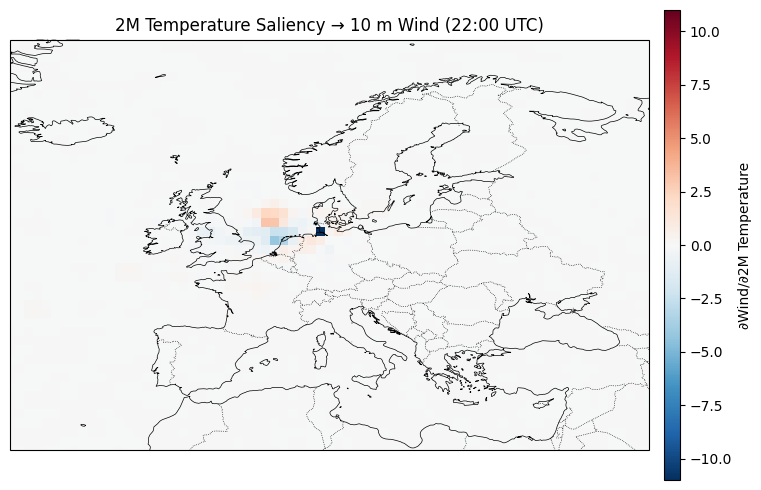

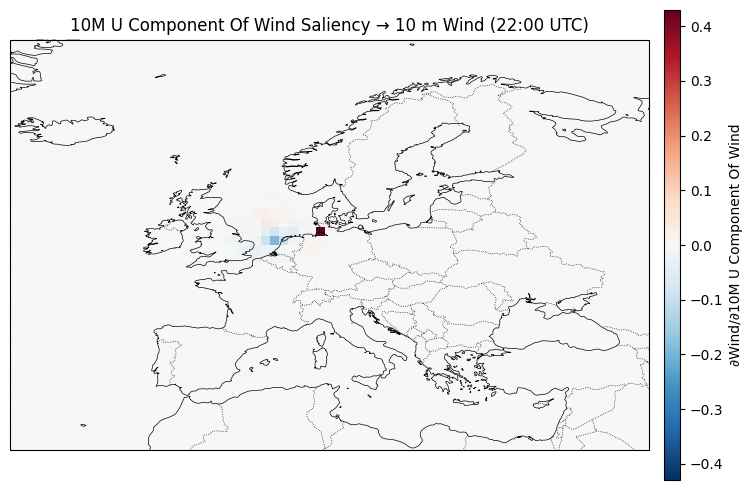

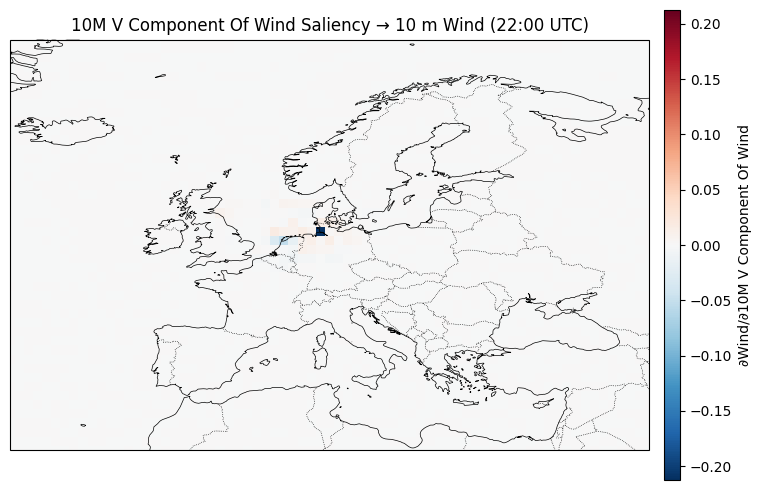

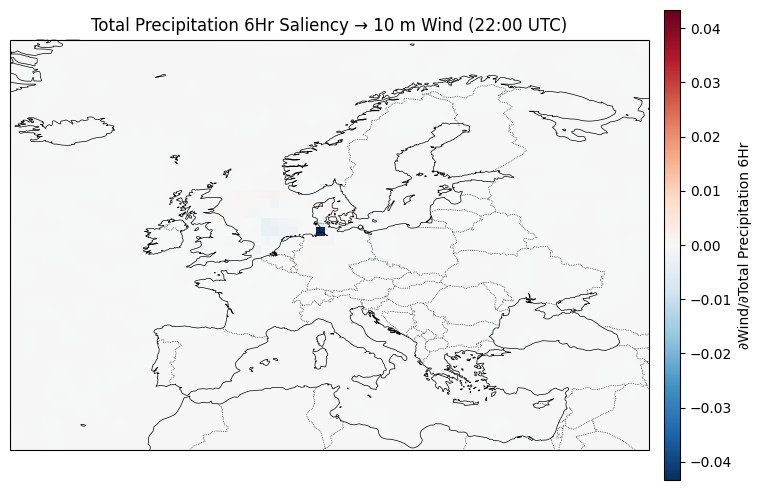

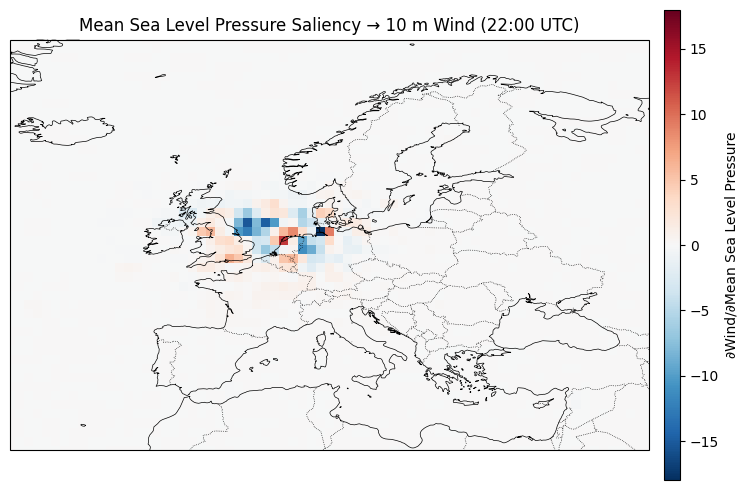

In [10]:
for surf_var in [
    "2m_temperature",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "total_precipitation_6hr",
    "mean_sea_level_pressure"
]:
    plot_surface_saliency(sal_ds_grad_x_input, input_ds, surf_var, time_index=-1)

Positive values mean increase of input values would also lead to increase of output

Negative values mean that a increase of the input value would lead to a decrease of the output

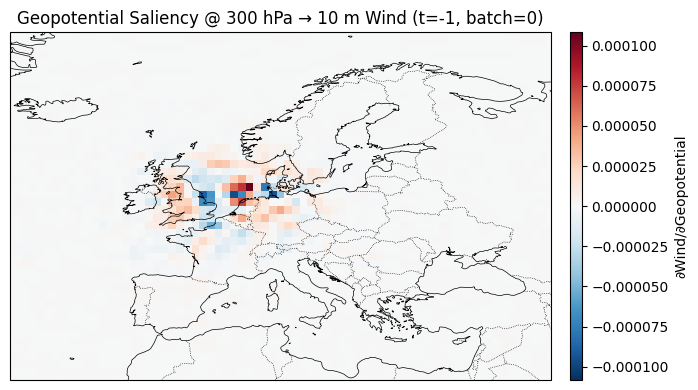

In [16]:
# variables: 
# geopotential, temperature, specific_humidity, 
# u_component_of_wind, v_component_of_wind, vertical_velocity

plot_atmospheric_saliency(
    sal_ds=sal_ds,
    input_ds=input_ds,
    varname="geopotential",
    target_level=300.0,
    time_index=-1,
    batch_index=0,
    extent=[-25, 45, 30, 75],
    cmap="RdBu_r"
)

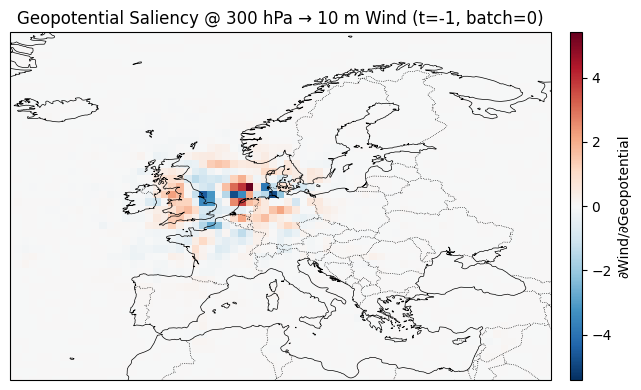

In [17]:
# variables: 
# geopotential, temperature, specific_humidity, 
# u_component_of_wind, v_component_of_wind, vertical_velocity

plot_atmospheric_saliency(
    sal_ds=sal_ds_grad_x_input,
    input_ds=input_ds,
    varname="geopotential",
    target_level=300.0,
    time_index=-1,
    batch_index=0,
    extent=[-25, 45, 30, 75],
    cmap="RdBu_r"
)

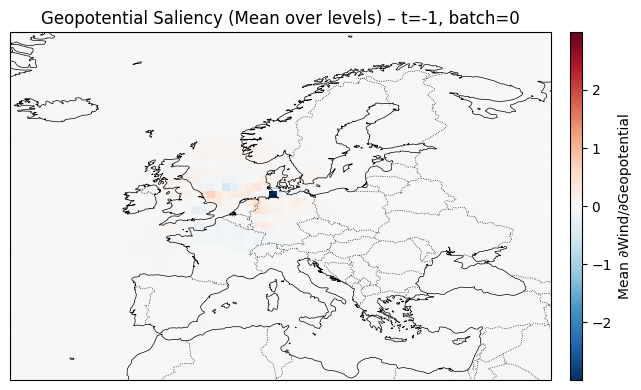

In [22]:
# Plot average geopotential saliency
plot_aggregated_saliency(
    sal_ds_grad_x_input, input_ds,
    varname="geopotential",
    time_index=-1,
    method="mean"
)